# GROVER'S SEARCH ALGORITHM

## Grover's Search Algorithm follows the steps given below:
- There are $N=2^n$ elements given.
- We are going to deal with $n$ qubits.
- First, we are going to apply Hadamard to all of our qubits. So we change our quantum state as superposition.
- Each basis state $ \ket{0 \cdots 0}, \ldots, \ket{1 \cdots 1} $ has an amplitude $ \frac{1}{\sqrt{N}} $.
- After all, we are going to iterate the following algorithm for more than once:
  1. Make a query:  At this level, we use a query oracle operator and apply it to our qubits. "This application flips the sign of the amplitude of the state that corresponds to the marked element."
  2. Inversion: "apply a diffusion matrix - the amplitude of each state is reflected over the mean of all amplitudes."

That's all! Let's implement this algorithm step by step.

In [99]:
# Our purpose: find the element you have chosen in the given list.
# Let's design a list of randomly chosen numbers.
the_list = [1, 5, 8, 9, 4, 3, 6, 7, 0, 1, 4]
# I want to find 7 in the_list and call it star.

In [100]:
# We should design an oracle. It is a black box that says:
# whether the number I have chosen is the star or not.
def the_oracle(the_input):
    star = 7
    if the_input == star:
        response = True
    else:
        response = False
    return response

In [118]:
# How many times should we call the oracle to find the actual star?
for index, trial_number in enumerate(the_list):
    if the_oracle(trial_number) == True:
        print("Star is found at index %i" %index)
        print("We call the the_oracle for %i times" %(index + 1))
        break

Star is found at index 7
We call the the_oracle for 8 times


### We have used classical computing so far. 
- While we are using classical computing, we should check $N/2$ times the elements of the the_list on average. This means we have to try every element of the the_list one by one. So, we need $N$ steps (i.e., the complexity of this problem is $O(N)$).

- But when we use quantum computing, we will figure out the problem by $\sqrt{N}$ (i.e., the complexity of this problem would be $O(\sqrt{N})$). 

### Let's start following the steps given above. 
Firstly, we try to follow those steps classically. Then, we try it one more time with quantum computing.

#### Following Steps with Classical Computing 
Note: This is an independent example from the "star = 7" example above. Here, we visualize the steps of Grover's algorithm (query, oracle, and inversion) on a list of 8 elements, where the marked element is the 3rd one.

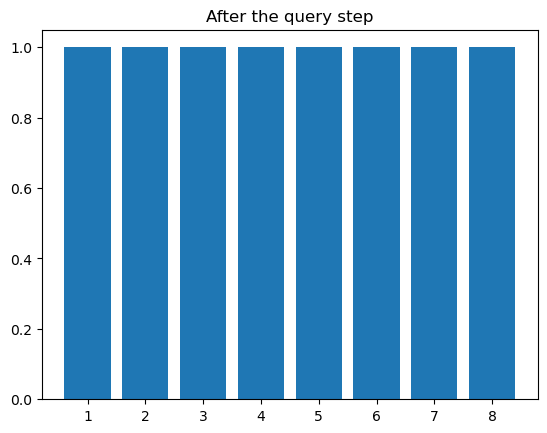

In [102]:
# The Query Step

# At the beginning, we want to create lists of elements and labels and visualize them as a bar plot.
import matplotlib.pyplot as plt

# Create empty lists with their labels and then assign numbers to lists:
bar_labels = []
bar_elements = []

for i in range(8):
    bar_labels.append(i + 1)
    bar_elements.append(1)

# Visualisation of the values of elements in the bar_elements list:
plt.bar(bar_labels, bar_elements)
plt.title("After the query step")
plt.show()

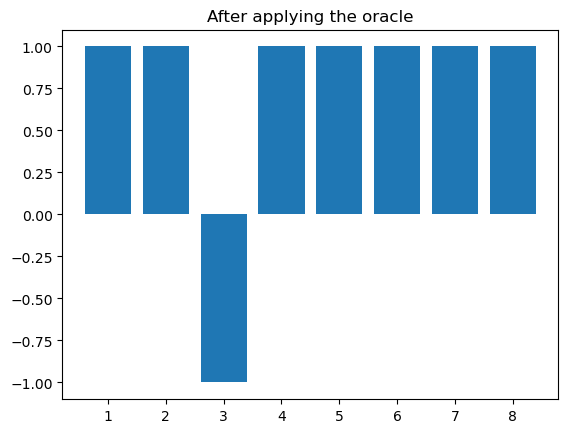

In [103]:
# The Oracle Step: Flip the sign of the marked (or the target) element.
marked_element = 3
bar_elements[marked_element - 1] = -1
plt.bar(bar_labels, bar_elements)
plt.title("After applying the oracle")
plt.show()

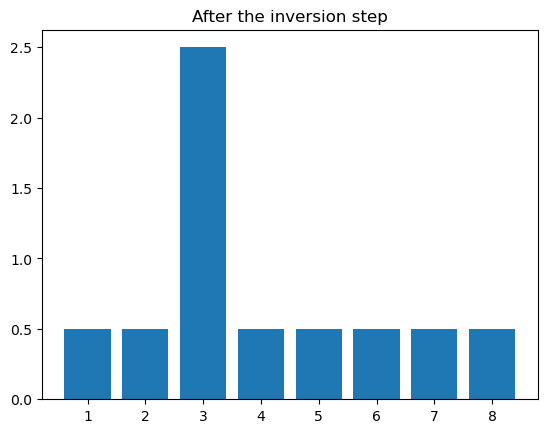

In [104]:
# The Inversion Step: Reflect on the mean.

# Sum all values:
sum_elements = 0
for element in range(len(bar_elements)):
    sum_elements += bar_elements[element]
    
# Calculate the mean of values:
mean = sum_elements / len(bar_elements)

# Reflection stage: Reflect on the mean
for value in range(len(bar_elements)):
    values = bar_elements[value]
    new_value = mean - (values - mean)
    bar_elements[value] = new_value

# Visualization:
plt.bar(bar_labels, bar_elements)
plt.title("After the inversion step")
plt.show()

#### Complexity: 

    - Our marked element is the third one in the list. 
    - It could be the first one or the last one. 
    - So, on average, the complexity of this problem requires 
    repeating $N/2$ times the steps above. 

At the end, the complexity of this problem is $O(N)$ in the classical case. 

##### Everything has been okay so far. Because our list has only 8 elements. But what if we have a list that has 100, 1000, or even more elements,and the element we are looking for is at the end?

#### There is a way for these kind of cases: The Grover's Search Algorithm.
This algorithm makes the complexities of these kind of problems $O(\sqrt{N})$.   

    So, let's try using it with another problem.

#### Following Steps with Quantum Computing 

In [105]:
# In this problem, our marked quantum state is |11⟩.

In [106]:
# Importing Step
# Note: We are going to use Qiskit in this notebook.
from qiskit import * 
from qiskit_aer import Aer
import matplotlib.pyplot as plt
import numpy as np

In [107]:
# Note: Our 

In [108]:
# Let's define the oracle circuit.
oracle = QuantumCircuit(2, name = "oracle") # Quantum circuit with two qubits
oracle.cz(0,1) # Apply controlled-Z gate, which flips the sign of our marked state.
oracle.to_gate()

# Visualize the oracle:
oracle.draw()

q_0: ─■─
      │ 
q_1: ─■─

In [109]:
# Is the oracle doing what we want to do? 
# We can check this by preparing a superposition state of all of my qubits by applying a Hadamard gate on each on of them.
# By doing this, I can query each one of the input state simultaneously to the oracle. 
backend = Aer.get_backend("statevector_simulator")
grover_circ = QuantumCircuit(2,2) # My Grover circuit with two qubits and two classical registers
grover_circ.h([0,1]) # Add Hadamard gate on both qubits 0 and 1 --> prepares all four superposition states
grover_circ.append(oracle,[0,1])

# Visualization:
grover_circ.draw()

┌───┐┌─────────┐
q_0: ┤ H ├┤0        ├
     ├───┤│  oracle │
q_1: ┤ H ├┤1        ├
     └───┘└─────────┘
c: 2/════════════════

In [110]:
# Execute this job on the simulator:
transpiled = transpile(grover_circ, backend)
job = backend.run(transpiled)
result = job.result()

In [111]:
# Get back the state vector:
sv = result.get_statevector()
np.around(sv,2)

array([ 0.5+0.j,  0.5+0.j,  0.5+0.j, -0.5+0.j])

As you can see from the given result above, the oracle flipped the sign of the amplitude of the $|11\rangle$ state.

### The oracle itself is not enough. 
We also need a reflection operator.
With both the oracle and the reflection operator, we can do something called **"amplitude amplification"**.
With amplitude amplification, we can amplify the probability of the marked state and reduce the probabilities of all the unmarked states. 

In [112]:
reflection = QuantumCircuit(2, name = "reflection")
reflection.h([0,1]) # from the superposition state  --> to the original state
reflection.z([0,1])
reflection.cz(0,1)
reflection.h([0,1])

# 2|s⟩⟨s| - I --> This is the mathematical process that we have gone through in this cell so far.
# |s⟩: equal superposition state --> |s⟩ = (|00⟩ + |01⟩ + |10⟩ + |11⟩) / 2
reflection.to_gate()

Instruction(name='reflection', num_qubits=2, num_clbits=0, params=[])

In [113]:
# How the reflection operator looks like:
reflection.draw()

┌───┐┌───┐   ┌───┐
q_0: ┤ H ├┤ Z ├─■─┤ H ├
     ├───┤├───┤ │ ├───┤
q_1: ┤ H ├┤ Z ├─■─┤ H ├
     └───┘└───┘   └───┘

In [114]:
# Let's put it all together.
backend = Aer.get_backend("qasm_simulator")
grover_circ = QuantumCircuit(2,2) # quantum circuit with two qubits and two classical registers
grover_circ.h([0,1]) # prepare the superposition state --> Hadamard on both qubits
grover_circ.append(oracle, [0,1]) # add the oracle
grover_circ.append(reflection, [0,1]) # add the reflection operator
grover_circ.measure([0,1], [0,1]) # add measurements at the very end

In [115]:
# What the circuit looks like: 
grover_circ.draw()

┌───┐┌─────────┐┌─────────────┐┌─┐   
q_0: ┤ H ├┤0        ├┤0            ├┤M├───
     ├───┤│  oracle ││  reflection │└╥┘┌─┐
q_1: ┤ H ├┤1        ├┤1            ├─╫─┤M├
     └───┘└─────────┘└─────────────┘ ║ └╥┘
c: 2/════════════════════════════════╩══╩═
                                     0  1

In [116]:
# What we want to get back at the very end is |11⟩.
transpiled = transpile(grover_circ, backend)
job = backend.run(transpiled, shots=1)
result = job.result()
result.get_counts()

{'11': 1}

#### With only one call, we get the result |11⟩.

### Sources:
- QWorld-Grover's Search: Implementation, prepared by Maksim Dimitrijev and Özlem Salehi
- Qiskit YouTube Channel-Grovers Algorithm — Programming on Quantum Computers — Coding with Qiskit S2E3 (https://www.youtube.com/watch?v=0RPFWZj7Jm0, Date Accessed: 11.03.2026)
- QTurkey-Grover Algoritması, Mert Çelik (https://kuantumturkiye.org/grover-algoritmasi/, Date Accessed: 11.03.2026)
- QWorld-Inversion About the Mean, prepared by Abuzer Yakaryilmaz

        This notebook was prepared by Hayrunnisa Özkan, 
        special thanks to the code and information from the sources given above. 
        March, 2026